LINEAR REGRESSION

Linear Regression is a supervised machine learning algorithm used to predict a continuous numeric value.
It assumes:
The relationship between input features (X) and output (Y) is linear.
This means we try to fit a straight line through the data.
For one feature:
👉 Equation
𝑦=𝑚𝑥+𝑐
Where:
m = slope   ,c = intercept    ,y = predicted value

With multiple features:

𝑦=𝑤1𝑥1+𝑤2𝑥2+𝑤3𝑥3+⋯​
💡 Intuition (Why Linear? Very simple)
Imagine you're predicting:
House Price based on size
Salary based on experience
Marks based on study hours
As X increases, Y also increases.
So we draw the best possible straight line such that the distance between actual and predicted values is minimum.

This distance is called error.

Linear Regression finds the line with minimum error → known as Ordinary Least Squares.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

In [25]:
# Example: predicting Salary based on Experience.

data = {
    'experience': [1,2,3,4,5,6,7,8,9,10],
    'salary':     [30,35,40,45,50,55,60,65,70,75]
}

df = pd.DataFrame(data)
# Step 3 — Define X (input) and y (output)

X = df[['experience']]

y = df['salary']

🔷 What is Train-Test Split?

Train-test split is a method in machine learning where we divide our dataset into two parts:
Training Set → used to train/fit the model
Test Set → used to evaluate the model
This means:

80% data → training

20% data → testing

🔥 Why do we use Train-Test Split? (Very Simple Explanation)
✔️ 1. To check if the model is genuinely learning

If you train a model on all the data, it may simply memorize it.
This is called overfitting.

✔️ 2. To test on unseen data
The test set acts like new real-world data.
We check:
Does the model perform well on new data?
Is it generalizing properly?

✔️ 3. To measure accuracy properly

We cannot evaluate on the same data that was used for training — it will always show high accuracy.
Test set shows the real performance.

📌 Simple Example to Understand

Imagine you're preparing for an exam.
You study from your book. (Training)
Then you take a mock test with new questions. (Testing)
If you test yourself using the same questions you studied, your score will be unrealistically high.

Same applies to ML models.

📘 How Train-Test Split works internally?

It:
Shuffles the data (randomizes order)
Splits it into training and test based on the percentage

test_size=0.2 → 20% test, 80% train
test_size=0.3 → 30% test, 70% train

Returns 4 parts:

X_train → training inputs
X_test → test inputs
y_train → training labels
y_test → test labels

In [26]:
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
# TRAIN THE MODEL
model=LinearRegression()
model.fit(X_train, y_train) #this step is used to train the data

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
# PREDICT
y_pred = model.predict(X_test)

In [29]:
# 🔥 To confirm model is fitted
# Try:

print(model.coef_)
print("\n")
print(model.intercept_)
# If it shows values → model is fitted.
# If it gives error → it's not fitted.

[5.]


24.999999999999996


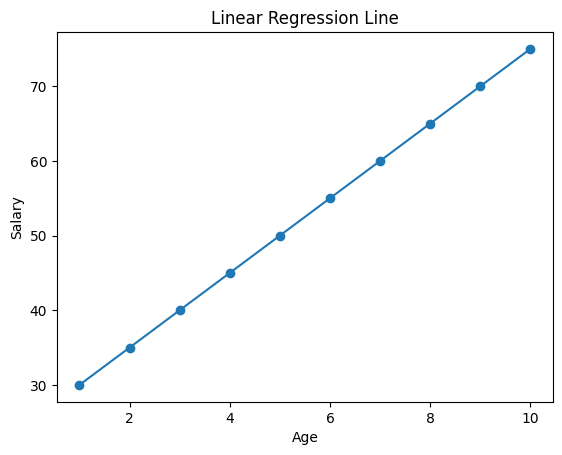

In [30]:
import matplotlib.pyplot as plt

# 1. SCATTER PLOT of actual points
plt.scatter(X, y)

# 2. PREDICTED LINE values
y_pred_line = model.predict(X)

# 3. REGRESSION LINE
plt.plot(X, y_pred_line)

plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Linear Regression Line")
plt.show()

MULTIPLE LINEAR REGRESSION

✅ 1. What is Multiple Linear Regression?

In simple linear regression:

👉 You have 1 input (X)
👉 And 1 output (Y)
👉 You draw 1 straight line.

Example:
Salary = f(Experience)

In Multiple Linear Regression:

👉 You have 2 or more inputs (features)
👉 And 1 output (target)
👉 You fit a plane or hyperplane, not a line.

Example:

Salary = f(Experience, Age, Education Level)

Formula:

𝑌=𝑏0+𝑏1𝑋1+𝑏2𝑋2+𝑏3𝑋3+...+𝑏𝑛𝑋𝑛
​
X1, X2, X3...Xn -> FEATURES
b1, b2, b3 ...bn-> WEIGHTS
b0 -> INTERCEPT

🎯 2. WHY do we use Multiple Linear Regression?

Use it when:
Output depends on multiple factors
You want to understand feature importance
You want to predict a continuous value
Examples:

Predicting house price using
area
number of bedrooms
location rating
age of house

Predicting student marks from
hours studied
previous scores
sleep time
attendance

🧠 3. IMPORTANT: Multiple Linear Regression needs ONLY numeric values!!

So you must convert categorical columns using:
One Hot Encoding

Label Encoding


In [42]:
data = {
    'area':     [1200,1500,1100,1800,2000,1700,1300,1600,1450,1900],
    'bedrooms': [2,   3,   2,   4,   4,   3,   2,   3,   3,   4],
    'age':      [10,  5,   20,  8,   5,   15,  8,   10,  12,  6],
    'price':    [135,185,120,250,270,210,150,195,180,260]     # Prices in thousands
}

In [43]:
#Convertin to dataframe
df = pd.DataFrame(data)
print(df)

   area  bedrooms  age  price
0  1200         2   10    135
1  1500         3    5    185
2  1100         2   20    120
3  1800         4    8    250
4  2000         4    5    270
5  1700         3   15    210
6  1300         2    8    150
7  1600         3   10    195
8  1450         3   12    180
9  1900         4    6    260


In [46]:

X = df[['area', 'bedrooms', 'age']] # Features
y = df['price']                 # Target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Model
y_pred = model.predict(X_test)

print("Predictions:", y_pred)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Predictions: [186.17318657 197.77320241 202.19512195]
Coefficients: [ 0.077344   31.93142224 -1.10468799]
Intercept: -8.513620525812172


IT IS VERY DIFFICULT TO PLOT THE GRAPH IN CASE OF MULTIPLE LINEAR REGRESSION
THAT IS WHY :
WE RATHER PLOT Plot Actual vs Predicted values (Most common)

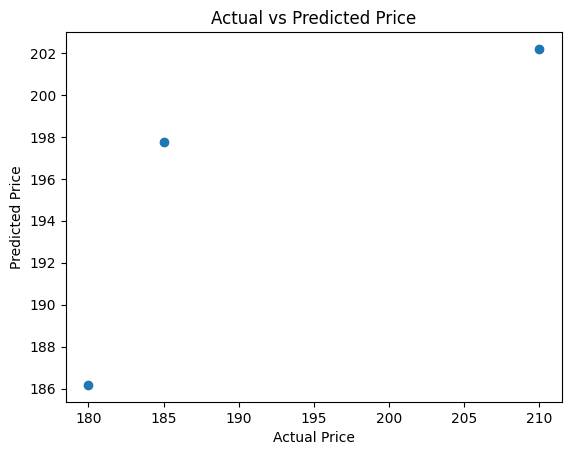

In [47]:

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

POLYNOMIAK REGRESSION

Polynomial Regression is still Linear Regression, but we add polynomial features to capture curved patterns.

Example:
In simple linear regression:
                              y=b0​+b1​x
But in polynomial regression (degree 2):
                              y=b0​+b1​x+b2​x^2
Degree 3:
                            y=b0​+b1​x+b2​x^2+b3​x^3  

🎯 2. When do we use Polynomial Regression?

Use it when:

Data shows curves
Trend is not straight
Linear Regression gives bad results
Examples:

Predicting ** car mileage vs speed **
Company sales over years
Growth curves

In [49]:
data = {
    'x':  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'y':  [5, 9, 15, 23, 35, 48, 65, 85, 110, 140]   # y follows a curve
}

df = pd.DataFrame(data)
print(df)

    x    y
0   1    5
1   2    9
2   3   15
3   4   23
4   5   35
5   6   48
6   7   65
7   8   85
8   9  110
9  10  140


In [50]:
from sklearn.preprocessing import PolynomialFeatures

X = df[['x']]
y = df['y']


# Step 2: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 👉 Step 3: Create Polynomial Features

# Degree 2 (Quadratic):

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly= poly.transform(X_test)

# This converts:
# x
# into:

# 1	x	x²  
# 1	2	4

# Step 4: Train the Polynomial Regression model
model = LinearRegression()
model.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
# Step 5: Predict values for curve
y_pred = model.predict(X_test_poly)

C:\Users\ishna\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


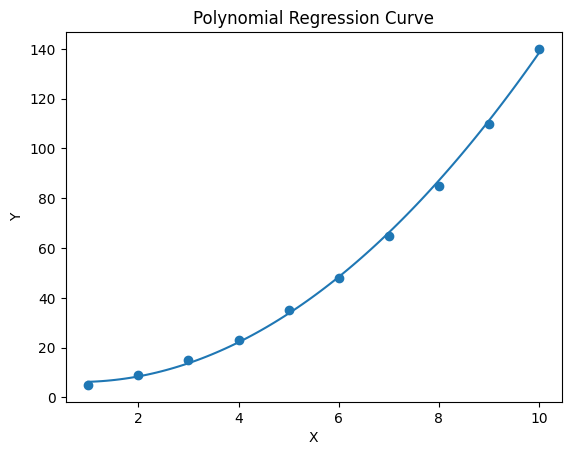

In [54]:
# 6. Plot Polynomial Regression Curve
plt.scatter(X, y)

# Generate smoother curve
X_curve = np.linspace(1, 10, 100).reshape(-1, 1)
X_curve_poly = poly.transform(X_curve)
y_curve_pred = model.predict(X_curve_poly)

plt.plot(X_curve, y_curve_pred)

plt.title("Polynomial Regression Curve")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

LOGISTIC REGRESSION
✅ LOGISTIC REGRESSION — FULL EXPLANATION (BEGINNER FRIENDLY)
1. What is Logistic Regression?

Logistic Regression is a classification algorithm used when the output (target variable) is categorical, usually binary:

✔ Yes/No
✔ 0/1
✔ Pass/Fail
✔ Spam/Not Spam
✔ Disease/No Disease

Unlike Linear Regression (which predicts numbers),
Logistic Regression predicts probabilities.

❗ Why is it called "Regression" then?

Because:
It uses a linear equation (like linear regression)
But instead of predicting a number, we pass the result through a Sigmoid function to convert it into a probability between 0 and 1.

🎯 2. Sigmoid Function — The Core Idea
Formula:
         σ(z)=1/(1+e^−z​)

         z=b0​+b1​x1​+b2​x2​+…
Then:
If output > 0.5 → Predict 1
If output ≤ 0.5 → Predict 0

📌 3. Where is Logistic Regression used? (VERY IMPORTANT)
Use Case	            Example
Email detection	     Spam or Not Spam
Bank	             Loan Approval
Healthcare	         Disease Prediction
Exams	             Pass/Fail
Marketing	         Will Customer Buy or Not

In [38]:
data = {
    'hours_studied': [1,2,3,4,5,6,7,8,9,10],
    'passed_exam':  [0,0,0,0,1,1,1,1,1,1]
}

df = pd.DataFrame(data)
print(df)


   hours_studied  passed_exam
0              1            0
1              2            0
2              3            0
3              4            0
4              5            1
5              6            1
6              7            1
7              8            1
8              9            1
9             10            1


In [39]:
from sklearn.linear_model import LogisticRegression

# Step 2: Prepare X and y
X = df[['hours_studied']]     # features
y = df['passed_exam']         # target

# Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 4: Train the model
model = LogisticRegression()
model.fit(X_train, y_train)

# Step 5: Predict
pred = model.predict(X_test)
print(pred)

# Step 6: Predict Probability
probs = model.predict_proba(X_test)
print(probs)

[1 0]
[[0.0060152  0.9939848 ]
 [0.93844742 0.06155258]]


C:\Users\ishna\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


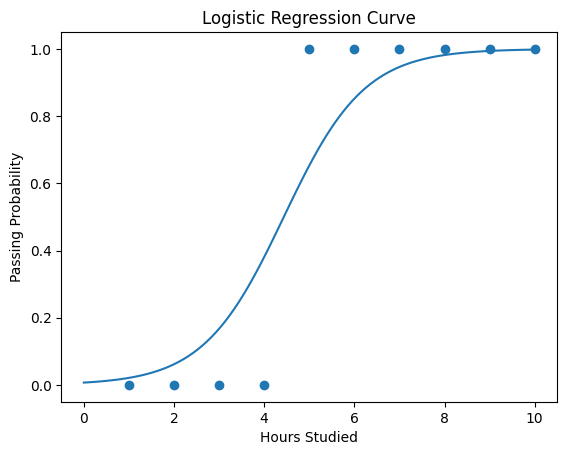

In [40]:
# 6. Visualizing Logistic Curve

import numpy as np
import matplotlib.pyplot as plt

# Plot curve
X_range = np.linspace(0, 10, 100).reshape(-1,1)
y_prob = model.predict_proba(X_range)[:,1]

plt.scatter(df['hours_studied'], df['passed_exam'])
plt.plot(X_range, y_prob)
plt.xlabel("Hours Studied")
plt.ylabel("Passing Probability")
plt.title("Logistic Regression Curve")
plt.show()